In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.utils import class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
import xgboost as xgb

In [3]:
from pipeline.data_pipeline import preprocessor, X, y, Z_damage

In [4]:
from helpers.neural_net_helpers import evaluate_and_find_best_threshold, generate_model_diagnostics, custom_objective_score

# Generate test, train and validation sets

In [5]:
# Data splitting into training, validation, and test sets
# First, split into a larger training set (train_full) and a test set
X_train_full, X_test, y_train_full, y_test, Z_damage_train_full, Z_damage_test = train_test_split(
    X, y, Z_damage,
    test_size=0.2,  # 20% for the final test set
    random_state=42,
    stratify=y if isinstance(y, pd.Series) and y.nunique() > 1 and not y.isnull().any() else None
)

# Now, split the train_full set into a final training set and a validation set
# For example, use 20% of train_full as validation (0.20 * 0.80 = 16% of total)
# This leaves 80% of train_full as the new training set (0.80 * 0.80 = 64% of total)
X_train, X_val, y_train, y_val, Z_damage_train, Z_damage_val = train_test_split(
    X_train_full, y_train_full, Z_damage_train_full,
    test_size=0.20, # 20% of X_train_full will be for validation
    random_state=42,
    stratify=y_train_full if isinstance(y_train_full, pd.Series) and y_train_full.nunique() > 1 and not y_train_full.isnull().any() else None
)

print(f"Shape of X: {X.shape}")
print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}, Z_damage_train: {Z_damage_train.shape}")
print(f"Shape of X_val: {X_val.shape}, y_val: {y_val.shape}, Z_damage_val: {Z_damage_val.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}, Z_damage_test: {Z_damage_test.shape}")

Shape of X: (155692, 16)
Shape of X_train: (99642, 16), y_train: (99642,), Z_damage_train: (99642,)
Shape of X_val: (24911, 16), y_val: (24911,), Z_damage_val: (24911,)
Shape of X_test: (31139, 16), y_test: (31139,), Z_damage_test: (31139,)


In [7]:
# Preprocess the data
print("Fitting preprocessor on X_train (the new, smaller training set)...")
preprocessor.fit(X_train) # Fit only on X_train

print("Transforming X_train...")
X_train_processed = preprocessor.transform(X_train)
print("Transforming X_val...")
X_val_processed = preprocessor.transform(X_val) # Transform the new validation set
print("Transforming X_test...")
X_test_processed = preprocessor.transform(X_test)

Fitting preprocessor on X_train (the new, smaller training set)...
Transforming X_train...
Transforming X_val...
Transforming X_test...


In [ ]:
# Ensure data is float32 for TensorFlow and target is also float32
X_train_processed = np.asarray(X_train_processed).astype('float32')
X_val_processed = np.asarray(X_val_processed).astype('float32')
X_test_processed = np.asarray(X_test_processed).astype('float32')

y_train = np.asarray(y_train).astype('float32')
y_val = np.asarray(y_val).astype('float32')
y_test = np.asarray(y_test).astype('float32')

Z_damage_train  = np.asarray(Z_damage_train).astype('float32') 
Z_damage_val    = np.asarray(Z_damage_val).astype('float32')
Z_damage_test   = np.asarray(Z_damage_test).astype('float32')

print(f"Shape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_val: {X_val_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

Shape of processed X_train: (99642, 62)
Shape of processed X_val: (24911, 62)
Shape of processed X_test: (31139, 62)


In [9]:
# Get the number of input features for the NN from the processed data
input_dim = X_train_processed.shape[1]

# Balancing the data

In [ ]:
# --- Resampling X, y, and Z together ---

# 1. Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# 2. Create and resample an array of positional indices
train_indices = np.arange(len(X_train_processed)).reshape(-1, 1)
resampled_indices_sparse, y_train_resampled = ros.fit_resample(train_indices, y_train)
resampled_indices = resampled_indices_sparse.flatten()

# 3. Use these positional indices with .iloc for pandas objects
#    and convert to NumPy arrays for consistency.

# For the NumPy array, standard indexing is fine
X_train_resampled = X_train_processed[resampled_indices]

# For the pandas Series, use .iloc to select by position, then get the NumPy array
if isinstance(Z_damage_train, pd.Series):
    Z_damage_train_resampled = Z_damage_train.iloc[resampled_indices].to_numpy()
else: # If it's already a NumPy array
    Z_damage_train_resampled = Z_damage_train[resampled_indices]

# Ensure the final output is float32 for TensorFlow
Z_damage_train_resampled = Z_damage_train_resampled.astype('float32')


# --- Verification ---
print("--- Original Data ---")
print(f"Original X_train shape: {X_train_processed.shape}")
print(f"Original Z_damage_train shape: {Z_damage_train.shape}")
print(f"Original class distribution: {Counter(y_train)}")

print("\n--- Resampled Data ---")
print(f"Resampled X_train shape: {X_train_resampled.shape}")
print(f"Resampled y_train shape: {y_train_resampled.shape}")
print(f"Resampled Z_damage_train shape: {Z_damage_train_resampled.shape}")
print(f"Resampled class distribution: {Counter(y_train_resampled)}")

--- Original Data ---
Original X_train shape: (99642, 62)
Original Z_damage_train shape: (99642,)
Original class distribution: Counter({np.float32(0.0): 96442, np.float32(1.0): 3200})

--- Resampled Data ---
Resampled X_train shape: (192884, 62)
Resampled y_train shape: (192884,)
Resampled Z_damage_train shape: (192884,)
Resampled class distribution: Counter({np.float32(0.0): 96442, np.float32(1.0): 96442})


In [ ]:
# Calculate class weights based on the original y_train distribution
# This will give higher weight to the minority class (Fraud)
class_weights_list = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Keras expects a dictionary for class_weight
class_weights_dict = {i : class_weights_list[i] for i, cls in enumerate(np.unique(y_train))}
class_weights_strategy1 = {0: 1.0, 1: 1.0}

print(f"\nCalculated Class Weights (based on original y_train): {class_weights_dict}")


Calculated Class Weights (based on original y_train): {0: np.float64(0.5165902822421766), 1: np.float64(15.5690625)}


# Model 1

In [12]:
model = Sequential([
    # Dense(512, activation='relu', input_shape=(input_dim,)),
    # Dropout(0.2),
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # ReLU activation for non-negative damage prediction
])

c:\Users\lol--\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# # Define the Neural Network model
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(input_dim,)),
#     Dropout(0.3),  # Dropout for regularization
#     Dense(64, activation='relu'),
#     Dropout(0.3),  # Dropout for regularization
#     Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification (output between 0 and 1)
# ])

In [14]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', # Suitable for binary classification problems
              metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,345 (224.00 KB)

 Trainable params: 57,345 (224.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Check for NaNs in y_train before training
if pd.Series(y_train).isnull().any():
    print(f"WARNING: y_train contains NaN values ({pd.Series(y_train).isnull().sum()} occurrences). This can lead to errors during training.")

In [16]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_acc',          # Monitor validation loss
    patience=30,                # Number of epochs with no improvement
    restore_best_weights=True,  # Restore weights from the best epoch
    mode='max'
)

In [17]:
# Train the model
print("Starting model training...")
history = model.fit(X_train_processed, y_train,
                    epochs=100,  # Number of times to iterate over the entire dataset
                    batch_size=32,  # Number of samples per gradient update
                    validation_data=(X_val_processed, y_val),
                    callbacks=[early_stopping],
                    verbose=1
)  # Set to 1 to see training progress, 0 for silent

# Evaluate the model on the test set
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nGenauigkeit des TensorFlow Modells auf den Testdaten: {accuracy:.4f}")
print(f"Verlust des TensorFlow Modells auf den Testdaten: {loss:.4f}")

Starting model training...
Epoch 1/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 3s 761us/step - accuracy: 0.9672 - loss: 0.1289 - val_accuracy: 0.9727 - val_loss: 0.1046
Epoch 2/100
 234/3114 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - accuracy: 0.9717 - loss: 0.1095

c:\Users\lol--\miniconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 752us/step - accuracy: 0.9714 - loss: 0.1075 - val_accuracy: 0.9729 - val_loss: 0.1048
Epoch 3/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 750us/step - accuracy: 0.9723 - loss: 0.1059 - val_accuracy: 0.9731 - val_loss: 0.1034
Epoch 4/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 755us/step - accuracy: 0.9722 - loss: 0.1050 - val_accuracy: 0.9727 - val_loss: 0.1016
Epoch 5/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 734us/step - accuracy: 0.9727 - loss: 0.1036 - val_accuracy: 0.9729 - val_loss: 0.1029
Epoch 6/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 746us/step - accuracy: 0.9730 - loss: 0.1029 - val_accuracy: 0.9720 - val_loss: 0.1016
Epoch 7/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 751us/step - accuracy: 0.9729 - loss: 0.1029 - val_accuracy: 0.9719 - val_loss: 0.1023
Epoch 8/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 773us/step - accuracy: 0.9730 - loss: 0.1021 - val_accuracy: 0.9721 - val_loss: 0.1015
Epoch 9/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 755us/step - accuracy: 0.9731 - los

# Evaluation

In [18]:
best_score, best_threshold = evaluate_and_find_best_threshold(model, X_test_processed, y_test, Z_damage_test)

print(f"The best achievable score is: {best_score}")
print(f"This score is achieved with a threshold of: {best_threshold}")

Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 281us/step
Identified 30928 unique thresholds to test.
The best achievable score is: -5712.72998046875
This score is achieved with a threshold of: 0.4925002455711365


## Understanding Model Evaluation with Imbalanced Data

You've noticed a huge disproportion between 0 and 1 values in your `y` data, which is common in scenarios like fraud detection, medical diagnosis, etc. Here's how to interpret the metrics and common strategies for handling this:

**Why Standard Accuracy Can Be Misleading:**
If 99% of your data is 'Normal' (class 0) and only 1% is 'Fraud' (class 1), a model that always predicts 'Normal' would achieve 99% accuracy. However, it would be useless for detecting fraud. This is why we need more nuanced metrics.

**Key Metrics for Imbalanced Datasets:**

* **Confusion Matrix**:
    * **True Positives (TP)**: Fraud cases correctly identified as Fraud.
    * **False Positives (FP)**: Normal cases incorrectly identified as Fraud (Type I error).
    * **True Negatives (TN)**: Normal cases correctly identified as Normal.
    * **False Negatives (FN)**: Fraud cases incorrectly identified as Normal (Type II error - often the most critical error in fraud detection).
* **Precision (for the positive class, e.g., 'Fraud')**: `TP / (TP + FP)`
    * Of all instances predicted as Fraud, how many were actually Fraud? High precision means fewer false alarms.
* **Recall (Sensitivity, True Positive Rate - TPR) (for 'Fraud')**: `TP / (TP + FN)`
    * Of all actual Fraud instances, how many did the model correctly identify? High recall means fewer missed fraud cases.
* **F1-Score (for 'Fraud')**: `2 * (Precision * Recall) / (Precision + Recall)`
    * The harmonic mean of Precision and Recall. Useful when you need a balance between them.
* **Balanced Accuracy**: `(Recall_class_0 + Recall_class_1) / 2` or `(TPR + Specificity) / 2`
    * The average of recall for each class. It's a better indicator of overall performance on imbalanced data than raw accuracy.
* **AUC-ROC (Area Under the ROC Curve)**:
    * Measures the model's ability to discriminate between positive and negative classes across all classification thresholds. An AUC of 1.0 is perfect, 0.5 is random.
* **AUC-PR (Area Under the Precision-Recall Curve)**:
    * Often more informative than AUC-ROC for highly imbalanced datasets, especially when the positive class is rare. It focuses on the performance on the minority (positive) class. A higher AUC-PR is better. The baseline is the fraction of positives.

**How to Handle Class Imbalance:**

1.  **Collect More Data**: If feasible, collecting more data for the minority class is often the best solution, though usually difficult.

2.  **Data-Level Approaches (Resampling)**:
    * **Oversampling the Minority Class**:
        * Randomly duplicate samples from the minority class.
        * **SMOTE (Synthetic Minority Over-sampling Technique)**: Creates synthetic samples for the minority class rather than just duplicating, which can be more effective.
    * **Undersampling the Majority Class**:
        * Randomly remove samples from the majority class. This can lead to loss of information.
    * **Combination of Oversampling and Undersampling**.

3.  **Algorithm-Level Approaches (Cost-Sensitive Learning)**:
    * Assign different weights to misclassifications. For example, penalize misclassifying a 'Fraud' instance (FN) more heavily than misclassifying a 'Normal' instance (FP).
    * In Keras, you can use the `class_weight` parameter in `model.fit()`. You would typically assign a higher weight to the minority class.

4.  **Choosing Appropriate Evaluation Metrics**: As done above, focus on metrics like Precision, Recall, F1-score, Balanced Accuracy, and AUC-PR rather than just overall accuracy.

5.  **Threshold Moving**:
    * The default threshold for converting probabilities to class labels is 0.5. For imbalanced datasets, this might not be optimal.
    * You can analyze the ROC curve or PR curve to choose a threshold that balances Precision and Recall according to your specific needs (e.g., maximize F1-score, or achieve a certain Recall level).

6.  **Using Different Algorithms**: Some algorithms are inherently better at handling imbalance or can be adapted for it (e.g., tree-based methods like Random Forest or Gradient Boosting often perform well, and some have built-in mechanisms or parameters for imbalance).

7.  **Anomaly Detection**: If the minority class is extremely rare and represents "anomalous" behavior, framing the problem as anomaly detection might be more appropriate.

The choice of strategy depends on the dataset, the problem, and the specific goals (e.g., is it more critical to minimize false negatives or false positives?). It often involves experimentation.

# Model 2

Now because the actual evaluation function penalizes not found Fraud more we want to change that for the model.

In [19]:
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

c:\Users\lol--\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Train the model using the resampled training data
# and the original (non-oversampled) validation data
history = model2.fit(
    X_train_resampled, y_train_resampled,  # Use resampled training data
    epochs=20,                             # Or your desired number of epochs
    batch_size=32,
    validation_data=(X_val_processed, y_val), # Use original validation data
    class_weight=class_weights_dict,          # Apply the calculated class weights
    verbose=1
)

# Evaluate the model on the original test set (as before)
print("\nEvaluating model on the original (non-resampled) test data...")
loss, accuracy = model2.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nGenauigkeit des TensorFlow Modells auf den Testdaten: {accuracy:.4f}")
print(f"Verlust des TensorFlow Modells auf den Testdaten: {loss:.4f}")

Epoch 1/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 601us/step - accuracy: 0.5018 - loss: 1.0332 - val_accuracy: 0.1105 - val_loss: 2.2634
Epoch 2/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 606us/step - accuracy: 0.5492 - loss: 0.8549 - val_accuracy: 0.2114 - val_loss: 2.0955
Epoch 3/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 627us/step - accuracy: 0.6003 - loss: 0.7855 - val_accuracy: 0.2645 - val_loss: 2.1398
Epoch 4/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 4s 588us/step - accuracy: 0.6265 - loss: 0.7491 - val_accuracy: 0.3098 - val_loss: 1.9451
Epoch 5/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 563us/step - accuracy: 0.6467 - loss: 0.7147 - val_accuracy: 0.3306 - val_loss: 1.9214
Epoch 6/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 569us/step - accuracy: 0.6574 - loss: 0.6965 - val_accuracy: 0.3613 - val_loss: 1.8433
Epoch 7/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 572us/step - accuracy: 0.6696 - loss: 0.6759 - val_accuracy: 0.3803 - val_loss: 1.8381
Epoch 8/20
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 3s 573us/step - accuracy: 0.6789 -

# Evaluation

In [21]:
best_score, best_threshold = evaluate_and_find_best_threshold(model2, X_test_processed, y_test, Z_damage_test)

print(f"The best achievable score is: {best_score}")
print(f"This score is achieved with a threshold of: {best_threshold}")

Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 247us/step
Identified 30425 unique thresholds to test.
The best achievable score is: -5180.64013671875
This score is achieved with a threshold of: 0.9990497827529907


# Regression Model

In [22]:
model_regression = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='relu')  # ReLU activation for non-negative damage prediction
])

model_regression.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error',  # MAE is often good for skewed targets
    metrics=['mean_absolute_error', 'mean_squared_error']
)

model_regression.summary()

c:\Users\lol--\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │        32,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,801 (800.00 KB)

 Trainable params: 204,801 (800.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping_reg = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Monitor validation loss
    patience=20,                # Number of epochs with no improvement
    restore_best_weights=True   # Restore weights from the best epoch
)

history_regression = model_regression.fit(
    X_train_resampled, Z_damage_train_resampled,        # Training with processed features and damage values as target
    epochs=100,                                         # Allow more epochs, early stopping will manage
    batch_size=32,
    validation_data=(X_val_processed, Z_damage_val),    # Validate with processed validation features and damage values
    callbacks=[early_stopping_reg],
    verbose=1
)

Epoch 1/100
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 2.9734 - mean_absolute_error: 2.9734 - mean_squared_error: 39.3000 - val_loss: 0.4286 - val_mean_absolute_error: 0.4286 - val_mean_squared_error: 3.6720
Epoch 2/100
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 6s 960us/step - loss: 2.5576 - mean_absolute_error: 2.5576 - mean_squared_error: 32.5293 - val_loss: 0.4284 - val_mean_absolute_error: 0.4284 - val_mean_squared_error: 3.8694
Epoch 3/100
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 6s 962us/step - loss: 2.3466 - mean_absolute_error: 2.3466 - mean_squared_error: 28.9582 - val_loss: 0.4182 - val_mean_absolute_error: 0.4182 - val_mean_squared_error: 3.7645
Epoch 4/100
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 6s 979us/step - loss: 2.2201 - mean_absolute_error: 2.2201 - mean_squared_error: 26.8970 - val_loss: 0.4245 - val_mean_absolute_error: 0.4245 - val_mean_squared_error: 3.9059
Epoch 5/100
6028/6028 ━━━━━━━━━━━━━━━━━━━━ 6s 973us/step - loss: 2.1329 - mean_absolute_error: 2.1329 - mean_squared_error: 25.790

In [24]:
best_score, best_threshold = evaluate_and_find_best_threshold(model_regression, X_test_processed, y_test, Z_damage_test)

print(f"The best achievable score is: {best_score}")
print(f"This score is achieved with a threshold of: {best_threshold}")

Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 331us/step
Identified 1391 unique thresholds to test.
The best achievable score is: -6770.31005859375
This score is achieved with a threshold of: 6.421042442321777


# Hurdle Model

In [ ]:
# --- 2. Prepare Targets for the Two-Part Hurdle Model ---
# The model has two outputs, so we need to create two corresponding target arrays
# from the existing Z_damage_train and Z_damage_val sets.

# Target 1: Binary classification (did damage occur?)
# We will use the existing y_train and y_val which already represent the binary indicator.

# Target 2: Regression on positive values (how much damage occurred?)
# We apply a log(1+x) transformation to handle the skewness of positive values.
# This is a crucial preprocessing step for the regression part.
y_continuous_log_train = np.log1p(Z_damage_train)
y_continuous_log_val = np.log1p(Z_damage_val)

print(f"Shape of binary target (train): {y_train.shape}")
print(f"Shape of continuous log-transformed target (train): {y_continuous_log_train.shape}")


# --- 3. Define Custom Loss Function for Regression Part ---
# This is a key component. The regression part of the model should only be trained
# on instances where damage actually occurred (Z_damage > 0). This custom loss
# function masks the loss calculation, ignoring the zero-damage instances.

def masked_mean_absolute_error(y_true, y_pred):
    """
    Calculates Mean Absolute Error only for true values greater than 0.
    This is used for the regression head of the hurdle model.
    """
    # Create a mask for values where the true value is positive.
    # We use the raw y_true (log-transformed) which is > 0 only if original Z > 0.
    mask = tf.cast(tf.greater(y_true, 0), dtype=tf.float32)

    # Calculate absolute error
    abs_error = tf.abs(y_true - y_pred)

    # Apply the mask
    masked_abs_error = abs_error * mask

    # Calculate the mean, but only over the non-masked elements
    # To do this, we sum the masked errors and divide by the number of non-zero elements.
    # Add a small epsilon to avoid division by zero if a batch has no positive samples.
    sum_masked_error = tf.reduce_sum(masked_abs_error)
    num_positive_samples = tf.reduce_sum(mask)
    
    return sum_masked_error / (num_positive_samples + tf.keras.backend.epsilon())


# --- 4. Build the Two-Part (Hurdle) Model using Keras Functional API ---
print("\n--- Building the Two-Part Hurdle Model ---")

# Get input dimension from the processed training data
input_dim = X_train_processed.shape[1]
inputs = tf.keras.layers.Input(shape=(input_dim,), name='input_features')

# Shared layers: these layers learn common patterns from the input data
# that are useful for both predicting occurrence and magnitude of damage.
shared = tf.keras.layers.Dense(128, activation='relu')(inputs)
shared = tf.keras.layers.Dropout(0.3)(shared)
shared = tf.keras.layers.Dense(64, activation='relu')(shared)
shared = tf.keras.layers.Dropout(0.3)(shared)

# Branch 1: Binary Classification Head (The "Hurdle")
# This branch predicts the probability of damage occurring (Z > 0).
binary_output = tf.keras.layers.Dense(1, activation='sigmoid', name='binary_output')(shared)

# Branch 2: Regression Head (The "Amount")
# This branch predicts the magnitude of the damage, conditional on it occurring.
# The 'relu' activation ensures the log-transformed prediction is non-negative.
regression_output = tf.keras.layers.Dense(1, activation='relu', name='regression_output')(shared)

# Create the final model with one input and two outputs
hurdle_model = tf.keras.models.Model(
    inputs=inputs,
    outputs=[binary_output, regression_output]
)

# Compile the model with two different loss functions and loss weights.
# The 'binary_output' uses standard binary crossentropy.
# The 'regression_output' uses our custom masked MAE.
hurdle_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'binary_output': 'binary_crossentropy',
        'regression_output': masked_mean_absolute_error
    },
    loss_weights={
        'binary_output': 1.0,
        'regression_output': 1.0
    },
    metrics={
        'binary_output': ['accuracy'],
        'regression_output': masked_mean_absolute_error
    }
)

hurdle_model.summary()


# --- 5. Train the Model ---
print("\n--- Training the Hurdle Model ---")

# Define the EarlyStopping callback. Crucially, set restore_best_weights=True.
# This ensures we keep the model from the epoch with the best validation performance.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitors the total validation loss (sum of both head losses)
    patience=20,
    restore_best_weights=True, # This is a critical best practice
    verbose=1
)

# Prepare the training and validation targets in a dictionary format
# that maps to the names of the output layers.
train_targets = {'binary_output': y_train, 'regression_output': y_continuous_log_train}
val_targets = {'binary_output': y_val, 'regression_output': y_continuous_log_val}

history = hurdle_model.fit(
    X_train_processed,
    train_targets,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_processed, val_targets),
    callbacks=[early_stopping],
    verbose=1
)



--- Preparing Targets for Hurdle Model ---
Shape of binary target (train): (99642,)
Shape of continuous log-transformed target (train): (99642,)

--- Building the Two-Part Hurdle Model ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │      8,064 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary_output       │ (None, 1)         │         65 │ dropout_10[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_output   │ (None, 1)         │         65 │ dropout_10[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,450 (64.26 KB)

 Trainable params: 16,450 (64.26 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the Hurdle Model ---
Epoch 1/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 3s 741us/step - binary_output_accuracy: 0.9646 - binary_output_loss: 0.1537 - loss: 0.6894 - regression_output_loss: 0.5357 - regression_output_masked_mean_absolute_error: 17.9386 - val_binary_output_accuracy: 0.9679 - val_binary_output_loss: 0.1187 - val_loss: 0.4871 - val_regression_output_loss: 0.3681 - val_regression_output_masked_mean_absolute_error: 13.5963
Epoch 2/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 714us/step - binary_output_accuracy: 0.9680 - binary_output_loss: 0.1273 - loss: 0.5337 - regression_output_loss: 0.4064 - regression_output_masked_mean_absolute_error: 14.3751 - val_binary_output_accuracy: 0.9681 - val_binary_output_loss: 0.1107 - val_loss: 0.4600 - val_regression_output_loss: 0.3491 - val_regression_output_masked_mean_absolute_error: 13.0261
Epoch 3/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 711us/step - binary_output_accuracy: 0.9684 - binary_output_loss: 0.1202 - loss: 0.5056 - regression_

In [26]:
class HurdleModelWrapper:
    """
    A wrapper for the two-part Keras hurdle model to make it compatible
    with evaluation functions that expect a single prediction output.
    """
    def __init__(self, keras_model):
        """
        Initializes the wrapper with a trained Keras hurdle model.
        
        Args:
            keras_model: The trained tf.keras.Model with two outputs.
        """
        self.keras_model = keras_model

    def predict(self, X_data):
        """
        Generates final predictions by combining the outputs of the two heads.
        This method mimics the standard model.predict() interface.
        
        Args:
            X_data: The input data for which to make predictions.
            
        Returns:
            A single, flattened numpy array of the final combined predictions.
        """
        # 1. Predict on the data using the underlying Keras model.
        # This returns a list of two arrays: [binary_pred, regression_log_pred]
        binary_pred, regression_log_pred = self.keras_model.predict(X_data)

        # 2. Back-transform the regression predictions from log(1+x) scale
        regression_pred = np.expm1(regression_log_pred)

        # 3. Calculate the final prediction: probability * amount
        final_pred = binary_pred * regression_pred

        # 4. Return the result as a flattened 1D array, as expected by the evaluation function
        return final_pred.flatten()

In [27]:
wrapped_hurdle_model = HurdleModelWrapper(hurdle_model)

In [28]:
best_score, best_threshold = evaluate_and_find_best_threshold(wrapped_hurdle_model, X_test_processed, y_test, Z_damage_test)

print(f"The best achievable score is: {best_score}")
print(f"This score is achieved with a threshold of: {best_threshold}")

Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step
Identified 31116 unique thresholds to test.
The best achievable score is: -4951.64990234375
This score is achieved with a threshold of: 1.8260554075241089


# Hurdle Model 2

In [29]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, Multiply
from tensorflow.keras.models import Model
import numpy as np

In [ ]:
inputs = Input(shape=(input_dim,), name='input_features')

# Shared layers (same as before)
shared = Dense(128, activation='relu')(inputs)
shared = Dropout(0.3)(shared)
shared = Dense(64, activation='relu')(shared)
shared = Dropout(0.3)(shared)

# --- Define the two heads before combining them ---

# Head 1: Probability Prediction
# This still outputs a value between 0 and 1.
binary_head = Dense(1, activation='sigmoid', name='binary_head')(shared)

# Head 2: Log-Damage Prediction
# This predicts log(1+damage) and must be transformed back.
regression_log_head = Dense(1, activation='relu', name='regression_log_head')(shared)

# --- Transform and Combine the Heads ---

# Step 1: Back-transform the regression head's output from log-scale to real scale.
# We use a Lambda layer to apply the expm1 function (e^x - 1).
regression_amount_head = Lambda(
    lambda x: tf.math.expm1(x), 
    name='regression_amount_head'
)(regression_log_head)

# Step 2: Multiply the probability by the predicted amount.
# The Multiply layer performs element-wise multiplication.
final_output = Multiply(name='final_expected_damage_output')(
    [binary_head, regression_amount_head]
)

# Create the final model with one input and ONE final output
combined_model = Model(inputs=inputs, outputs=final_output)


# --- Compile the Model ---
# Now we use a standard regression loss function, like MAE.
combined_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error', # Training the 'expected damage' to match the true damage
    metrics=['mean_absolute_error']
)

combined_model.summary()


# The model now expects a single target: the true damage amount.
history = combined_model.fit(
    X_train_processed,
    Z_damage_train,  # We use the original damage values as the target
    epochs=100,
    batch_size=32,
    validation_data=(X_val_processed, Z_damage_val),
    callbacks=[early_stopping],
    verbose=1
)


--- Building the Combined, Single-Output Hurdle Model ---



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │      8,064 │ input_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      8,256 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_log_head │ (None, 1)         │         65 │ dropout_12[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary_head (Dense) │ (None, 1)         │         65 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_amount_… │ (None, 1)         │          0 │ regression_log_h… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_expected_dam… │ (None, 1)         │          0 │ binary_head[0][0… │
│ (Multiply)          │                   │            │ regression_amoun… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,450 (64.26 KB)

 Trainable params: 16,450 (64.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 3s 656us/step - loss: 0.2515 - mean_absolute_error: 0.2515 - val_loss: 0.2569 - val_mean_absolute_error: 0.2569
Epoch 2/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 661us/step - loss: 0.2497 - mean_absolute_error: 0.2497 - val_loss: 0.2569 - val_mean_absolute_error: 0.2569
Epoch 3/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 657us/step - loss: 0.2497 - mean_absolute_error: 0.2497 - val_loss: 0.2569 - val_mean_absolute_error: 0.2569
Epoch 4/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 668us/step - loss: 0.2497 - mean_absolute_error: 0.2497 - val_loss: 0.2569 - val_mean_absolute_error: 0.2569
Epoch 5/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 651us/step - loss: 0.2497 - mean_absolute_error: 0.2497 - val_loss: 0.2569 - val_mean_absolute_error: 0.2569
Epoch 6/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 657us/step - loss: 0.2497 - mean_absolute_error: 0.2497 - val_loss: 0.2569 - val_mean_absolute_error: 0.2569
Epoch 7/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 2s 654us/step - loss: 0.249

# Hurdle Model 3

In [31]:
from tensorflow.keras import backend as K
import tensorflow as tf

def tweedie_loss(y_true, y_pred):
    """
    Custom Tweedie loss function for Keras.
    p=1.5 corresponds to a compound Poisson-Gamma distribution.
    """
    p = 1.5
    
    # 1. Clip predictions to avoid log(0) or division by zero.
    #    A very small positive number (epsilon) is used as the minimum.
    y_pred = K.clip(y_pred, K.epsilon(), None)
    
    # 2. The Tweedie loss formula, using Keras backend functions
    #    Note: K.pow() is used instead of np.exp()
    a = y_true * K.pow(y_pred, 1 - p) / (1 - p)
    b = K.pow(y_pred, 2 - p) / (2 - p)
    
    loss = -a + b
    
    # 3. Return the mean loss over the batch
    return K.mean(loss)

In [ ]:
model_regression2 = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='relu')  # ReLU activation for non-negative damage prediction
])

# Compile the model
model_regression2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tweedie_loss,
    metrics=['mean_absolute_error', 'mean_squared_error']
)

model_regression2.summary()

c:\Users\lol--\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │        32,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,801 (800.00 KB)

 Trainable params: 204,801 (800.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stopping_reg = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Monitor validation loss
    patience=20,                # Number of epochs with no improvement
    restore_best_weights=True   # Restore weights from the best epoch
)

history_regression = model_regression2.fit(
    X_train_processed, Z_damage_train,        # Training with processed features and damage values as target
    epochs=100,                                         # Allow more epochs, early stopping will manage
    batch_size=32,
    validation_data=(X_val_processed, Z_damage_val),    # Validate with processed validation features and damage values
    callbacks=[early_stopping_reg],
    verbose=1
)

Epoch 1/100


3114/3114 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1579.1146 - mean_absolute_error: 0.2501 - mean_squared_error: 3.6466 - val_loss: 1624.6771 - val_mean_absolute_error: 0.2569 - val_mean_squared_error: 3.8011
Epoch 2/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1579.1125 - mean_absolute_error: 0.2497 - mean_squared_error: 3.6465 - val_loss: 1624.6771 - val_mean_absolute_error: 0.2569 - val_mean_squared_error: 3.8011
Epoch 3/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1579.1125 - mean_absolute_error: 0.2497 - mean_squared_error: 3.6465 - val_loss: 1624.6771 - val_mean_absolute_error: 0.2569 - val_mean_squared_error: 3.8011
Epoch 4/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1579.1125 - mean_absolute_error: 0.2497 - mean_squared_error: 3.6465 - val_loss: 1624.6771 - val_mean_absolute_error: 0.2569 - val_mean_squared_error: 3.8011
Epoch 5/100
3114/3114 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1579.1125 - mean_absolute_error: 0.2497 - mean_squared_error: 3.6

# XGBoost

In [ ]:
print(f"Verwende XGBoost Version: {xgb.__version__}")

# Wir müssen eine feste Anzahl von Runden (n_estimators) wählen.
# 200 ist ein vernünftiger Startpunkt.
xgb_model_no_es = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=200,      # Feste Anzahl an Trainingsrunden
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model_no_es.fit(X_train_processed, y_train)

Verwende XGBoost Version: 3.0.2

Starte das Training des XGBoost-Modells (ohne Early Stopping)...
Training abgeschlossen.


# Evaluate all models

In [35]:
class AlwaysZeroPredictor:
    """
    A dummy model that always predicts 0.
    Its .predict() method matches the interface of a trained model.
    """
    def predict(self, X_data):
        """
        Generates an array of zeros with the same length as the input data.
        """
        n_samples = len(X_data)
        return np.zeros(n_samples)

class RandomPredictor:
    """
    A dummy model that randomly predicts 1 for a given percentage of samples
    and 0 for the rest.
    """
    def __init__(self, ratio=0.10, seed=None):
        """
        Initializes the predictor with a specified ratio of positive predictions.
        
        Args:
            ratio (float): The proportion of samples to be randomly labeled as 1.
            seed (int, optional): A random seed for reproducible results.
        """
        self.ratio = ratio
        self.seed = seed
        
    def predict(self, X_data):
        """
        Generates a random prediction array.
        """
        # Use the seed if one was provided to ensure reproducibility
        if self.seed is not None:
            np.random.seed(self.seed)
            
        n_samples = len(X_data)
        predictions = np.zeros(n_samples, dtype=int)
        n_ones = int(n_samples * self.ratio)
        
        indices_to_be_one = np.random.permutation(n_samples)[:n_ones]
        predictions[indices_to_be_one] = 1
        
        return predictions

In [36]:
# --- Instantiate the reference models ---
always_zero_baseline = AlwaysZeroPredictor()
random_10_percent_baseline = RandomPredictor(ratio=0.10, seed=42) # Using a seed for consistency

In [37]:
# --- Complete list of models to evaluate ---
models_to_evaluate = [
    # Baseline models
    {'name': 'Reference: Always Zero', 'model': always_zero_baseline},
    {'name': 'Reference: Random 10%', 'model': random_10_percent_baseline},

    # Trained models
    {'name': 'Classification', 'model': model},
    {'name': 'Oversampling Classification', 'model': model2},
    {'name': 'Regression', 'model': model_regression},
    {'name': 'Hurdle', 'model': wrapped_hurdle_model},
    {'name': 'Combined', 'model': combined_model},
    {'name': 'XGBoost', 'model': xgb_model_no_es},
    {'name': 'Tweedie', 'model': model_regression2}
]

In [38]:
generate_model_diagnostics(models_to_evaluate, X_test_processed, y_test, Z_damage_test, show_plots=False)

--- Generating Comprehensive Model Diagnostics ---

==================== DIAGNOSTICS FOR: Reference: Always Zero ====================
Generating predictions from the model...
Identified 2 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -7871.00
  🖯 Optimal Threshold: 1.0000
---------------
AUC-ROC Score: 0.5000
AUC-PR Score (Average Precision): 0.0321
==================== END DIAGNOSTICS FOR: Reference: Always Zero ====================


==================== DIAGNOSTICS FOR: Reference: Random 10% ====================
Generating predictions from the model...
Identified 3 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -7871.00
  🖯 Optimal Threshold: 2.0000
---------------
AUC-ROC Score: 0.5114
AUC-PR Score (Average Precision): 0.0330
==================== END DIAGNOSTICS FOR: Reference: Random 10% ====================


==================== DIAGNOSTICS FOR: Classification ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 279us/step
Generating pred

--- Generating Comprehensive Model Diagnostics ---

==================== DIAGNOSTICS FOR: Reference: Always Zero ====================
Generating predictions from the model...
Identified 2 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -7871.00
  🖯 Optimal Threshold: 1.0000
---------------


--- 1. Performance at Optimal Threshold ---



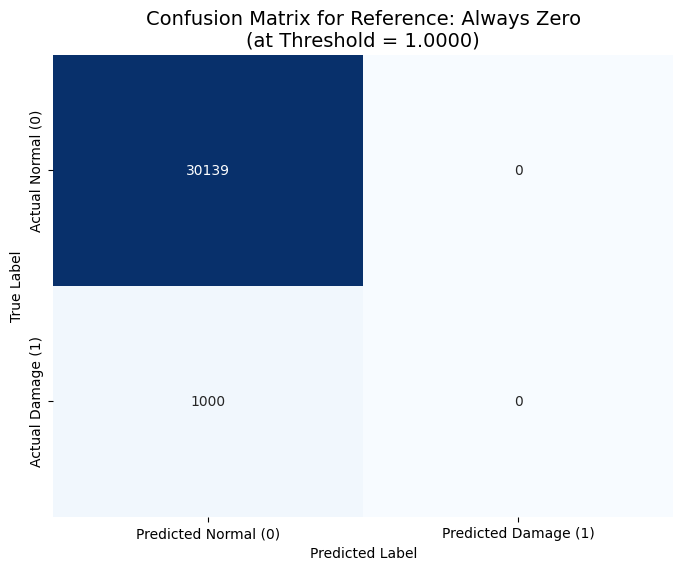


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.97      1.00      0.98     30139
   Damage (1)       0.00      0.00      0.00      1000

     accuracy                           0.97     31139
    macro avg       0.48      0.50      0.49     31139
 weighted avg       0.94      0.97      0.95     31139



--- 2. Overall Classifier Performance ---



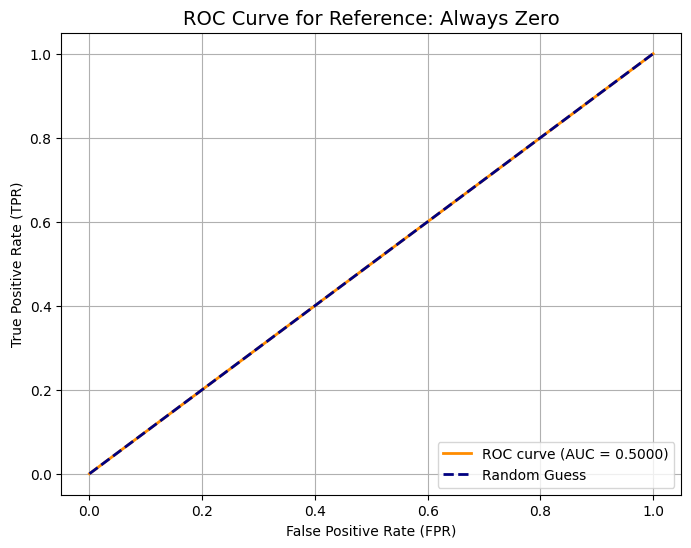

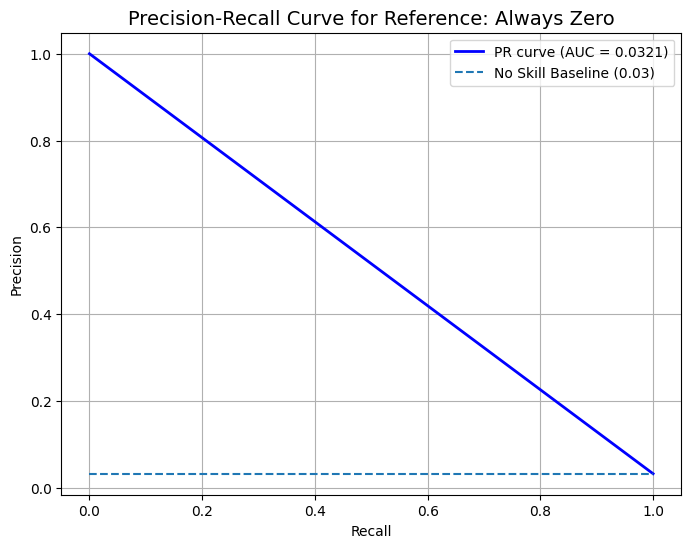

AUC-ROC Score: 0.5000
AUC-PR Score (Average Precision): 0.0321


--- 3. Damage Prediction Visualization ---



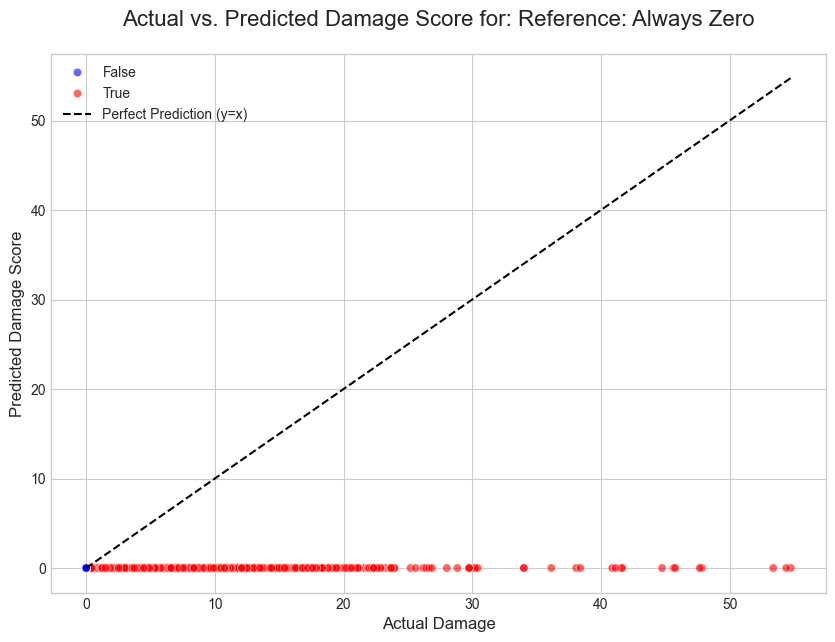

==================== END DIAGNOSTICS FOR: Reference: Always Zero ====================


==================== DIAGNOSTICS FOR: Reference: Random 10% ====================
Generating predictions from the model...
Identified 3 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -7871.00
  🖯 Optimal Threshold: 2.0000
---------------


--- 1. Performance at Optimal Threshold ---



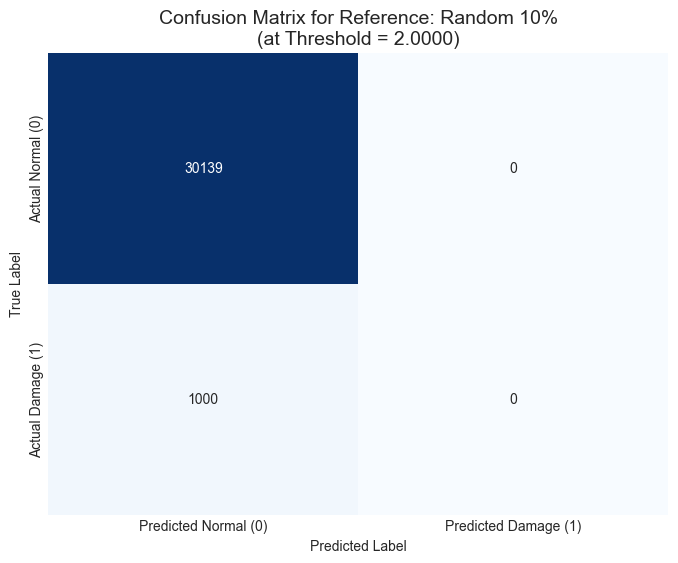


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.97      1.00      0.98     30139
   Damage (1)       0.00      0.00      0.00      1000

     accuracy                           0.97     31139
    macro avg       0.48      0.50      0.49     31139
 weighted avg       0.94      0.97      0.95     31139



--- 2. Overall Classifier Performance ---



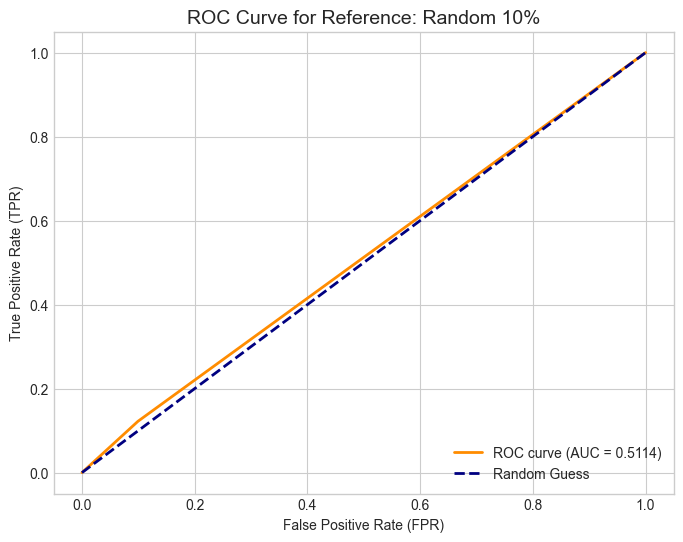

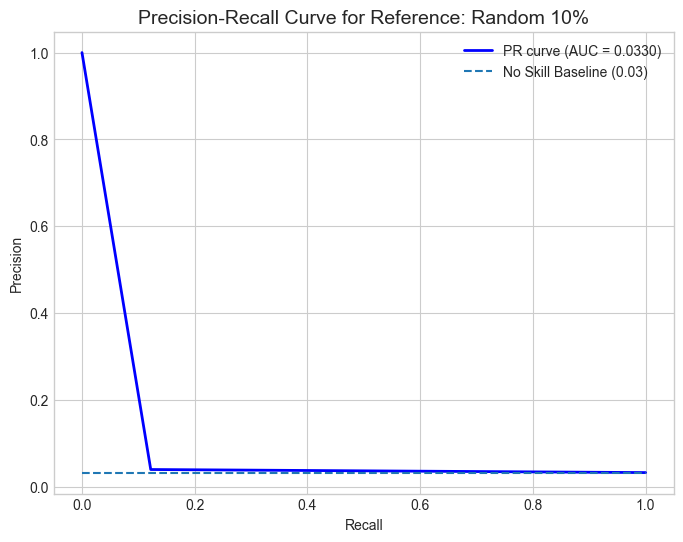

AUC-ROC Score: 0.5114
AUC-PR Score (Average Precision): 0.0330


--- 3. Damage Prediction Visualization ---



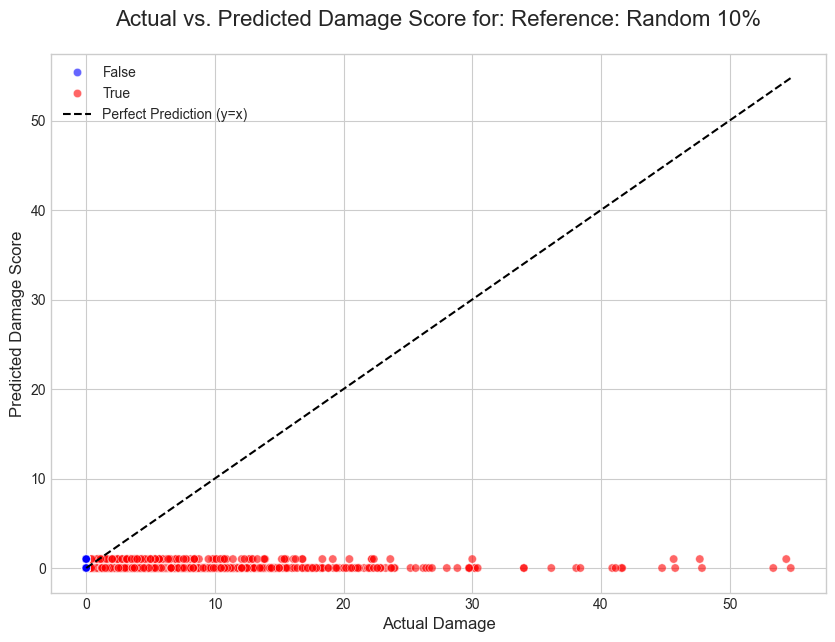

==================== END DIAGNOSTICS FOR: Reference: Random 10% ====================


==================== DIAGNOSTICS FOR: Classification ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step
Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step
Identified 30928 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -5712.73
  🖯 Optimal Threshold: 0.4925
---------------


--- 1. Performance at Optimal Threshold ---



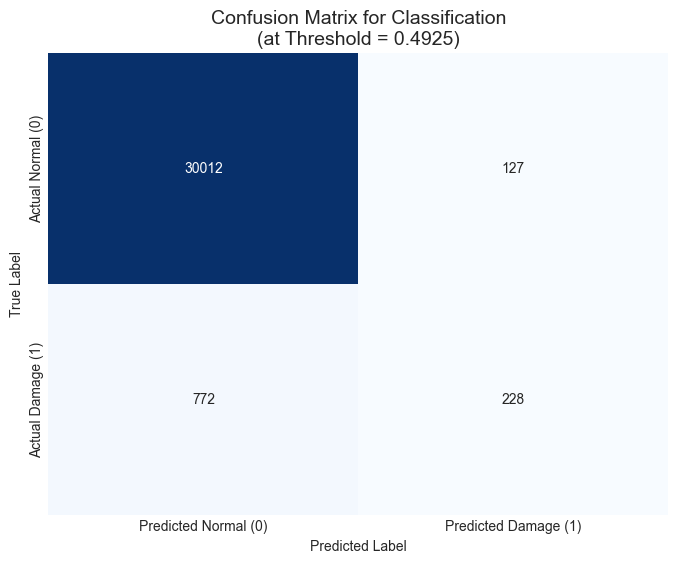


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.97      1.00      0.99     30139
   Damage (1)       0.64      0.23      0.34      1000

     accuracy                           0.97     31139
    macro avg       0.81      0.61      0.66     31139
 weighted avg       0.96      0.97      0.96     31139



--- 2. Overall Classifier Performance ---



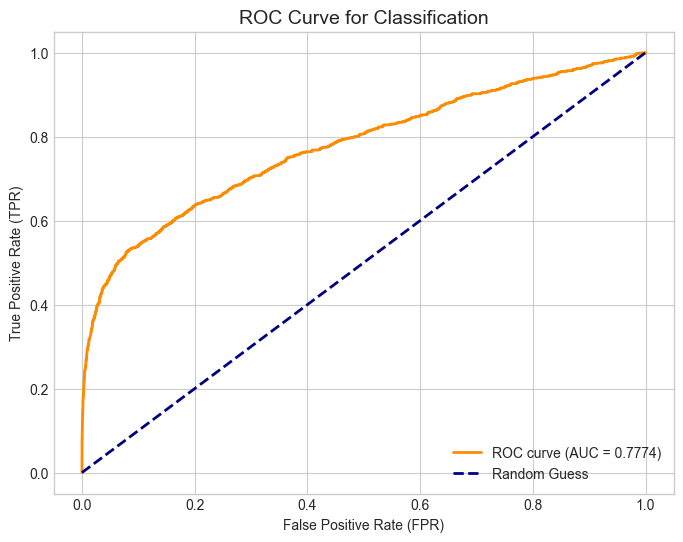

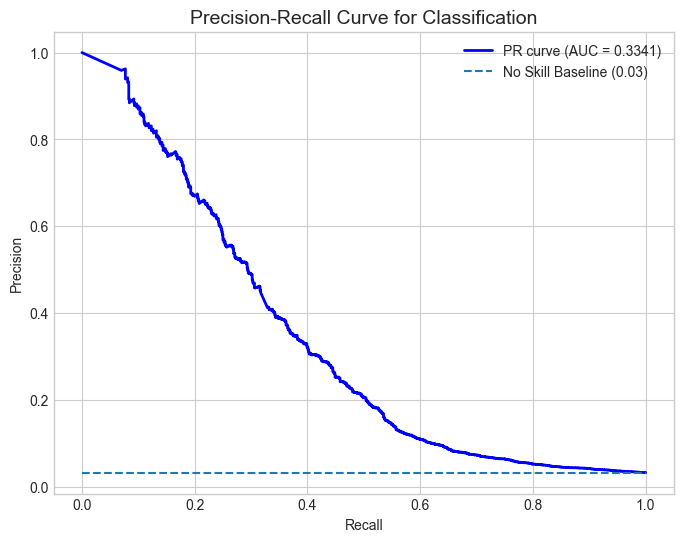

AUC-ROC Score: 0.7774
AUC-PR Score (Average Precision): 0.3341


--- 3. Damage Prediction Visualization ---



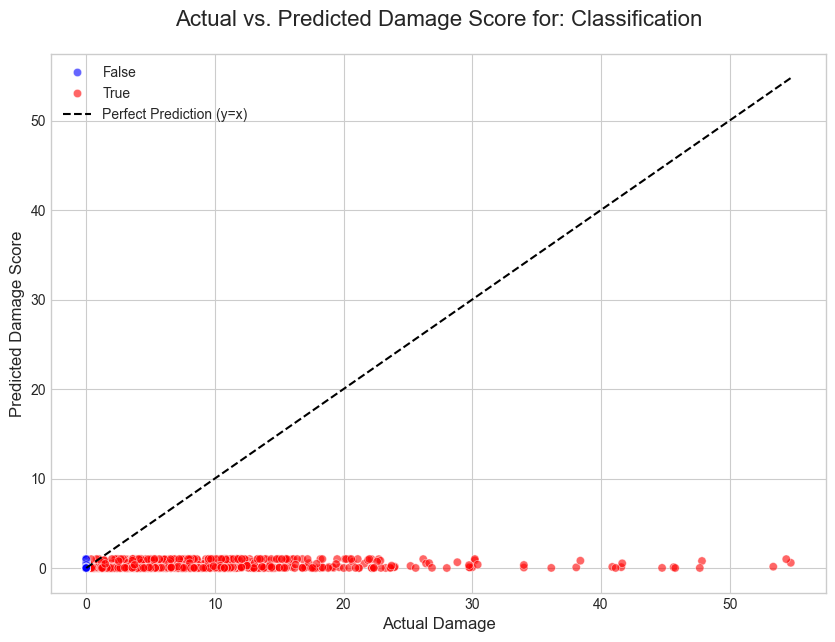

==================== END DIAGNOSTICS FOR: Classification ====================


==================== DIAGNOSTICS FOR: Oversampling Classification ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step
Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step
Identified 30425 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -5180.64
  🖯 Optimal Threshold: 0.9990
---------------


--- 1. Performance at Optimal Threshold ---



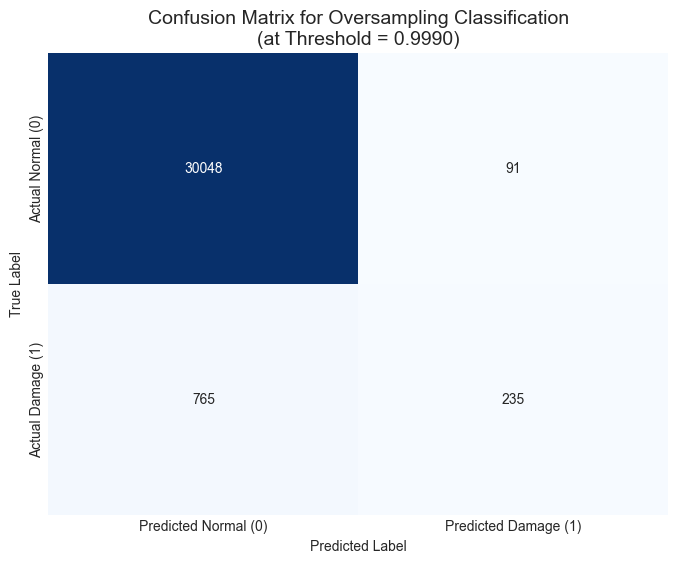


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.98      1.00      0.99     30139
   Damage (1)       0.72      0.23      0.35      1000

     accuracy                           0.97     31139
    macro avg       0.85      0.62      0.67     31139
 weighted avg       0.97      0.97      0.97     31139



--- 2. Overall Classifier Performance ---



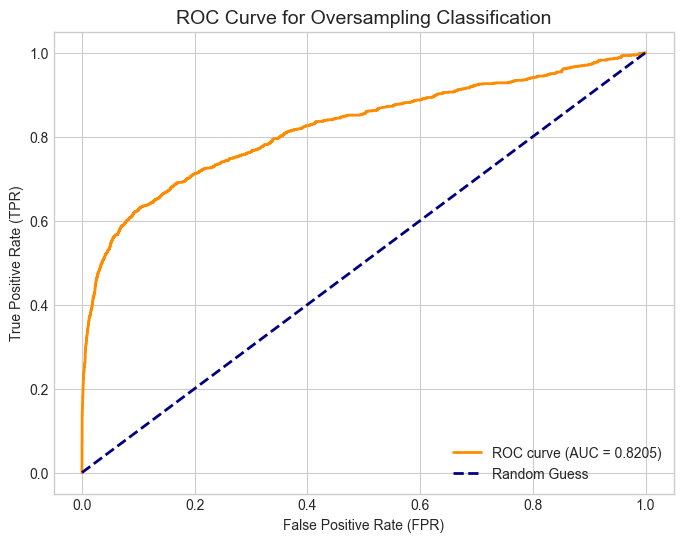

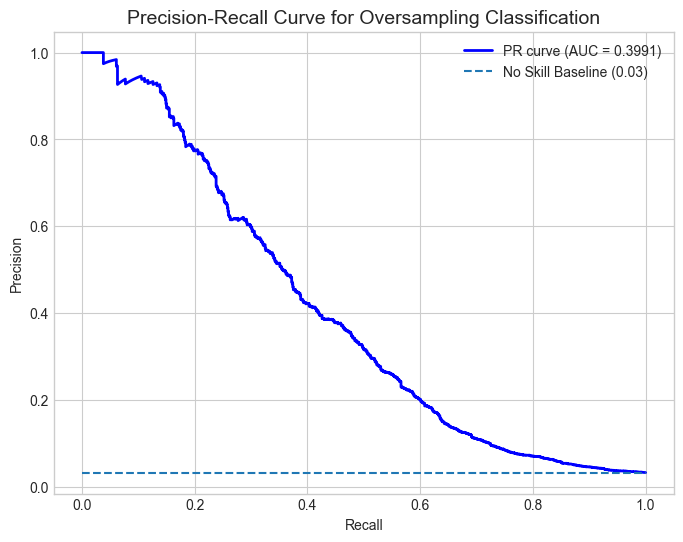

AUC-ROC Score: 0.8205
AUC-PR Score (Average Precision): 0.3991


--- 3. Damage Prediction Visualization ---



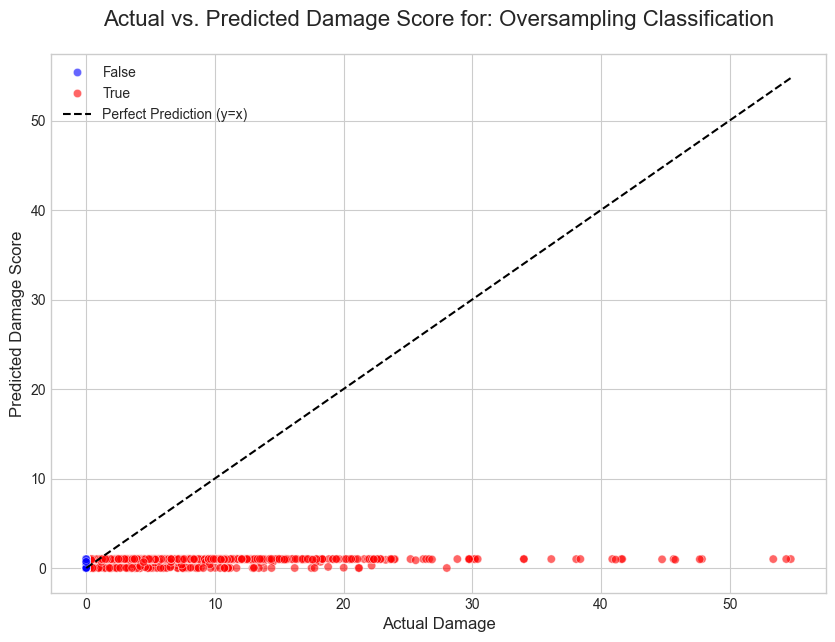

==================== END DIAGNOSTICS FOR: Oversampling Classification ====================


==================== DIAGNOSTICS FOR: Regression ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step
Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step
Identified 1391 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -6770.31
  🖯 Optimal Threshold: 6.4210
---------------


--- 1. Performance at Optimal Threshold ---



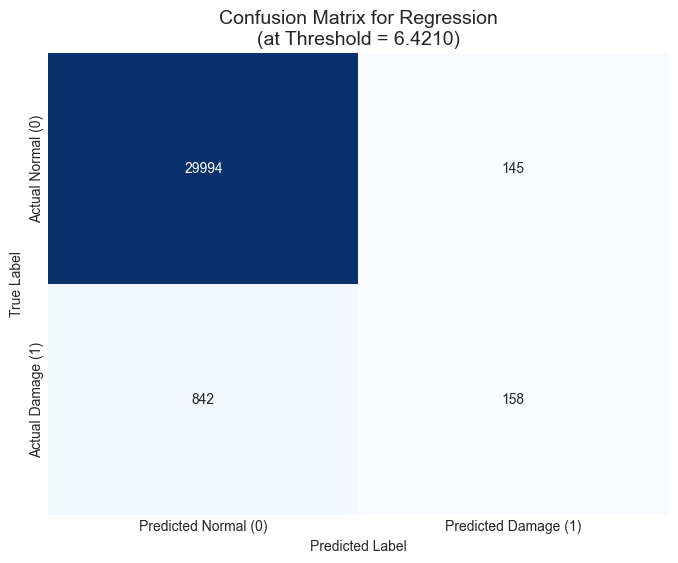


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.97      1.00      0.98     30139
   Damage (1)       0.52      0.16      0.24      1000

     accuracy                           0.97     31139
    macro avg       0.75      0.58      0.61     31139
 weighted avg       0.96      0.97      0.96     31139



--- 2. Overall Classifier Performance ---



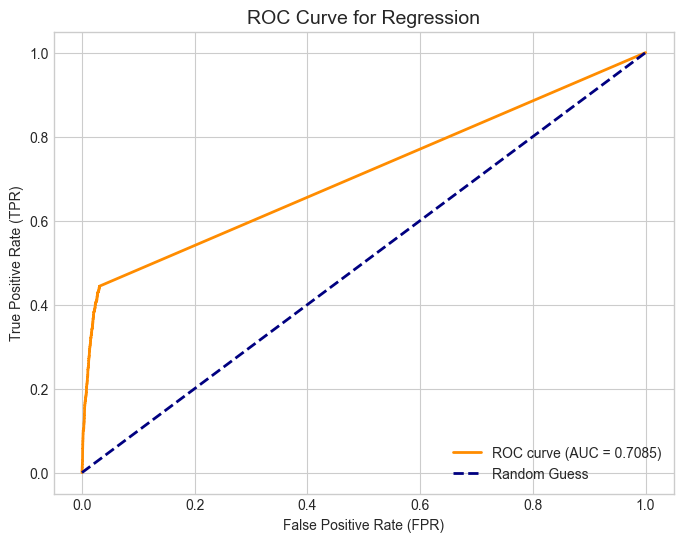

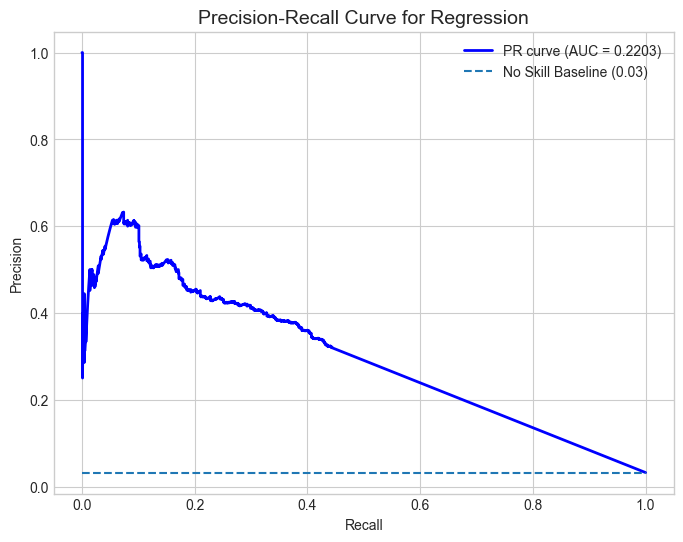

AUC-ROC Score: 0.7085
AUC-PR Score (Average Precision): 0.2203


--- 3. Damage Prediction Visualization ---



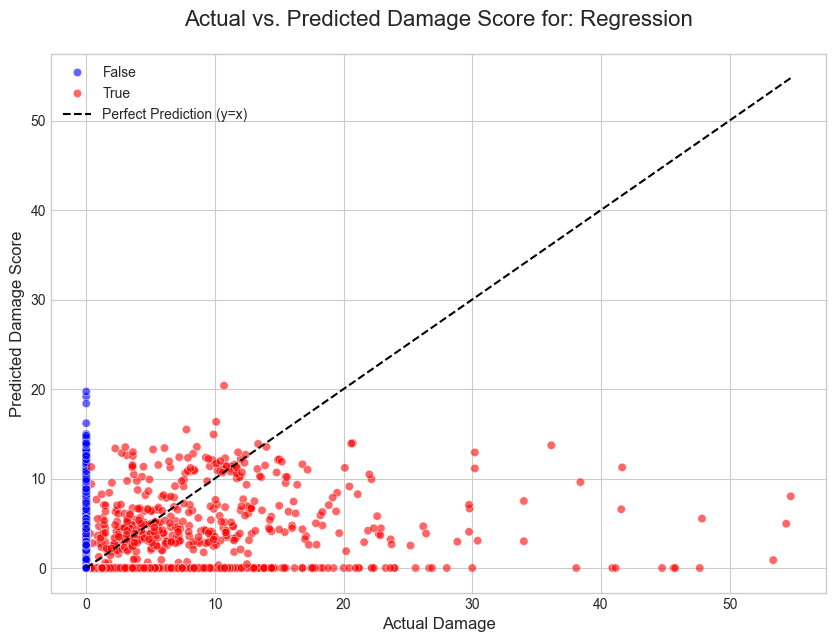

==================== END DIAGNOSTICS FOR: Regression ====================


==================== DIAGNOSTICS FOR: Hurdle ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step
Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step
Identified 31116 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -4951.65
  🖯 Optimal Threshold: 1.8261
---------------


--- 1. Performance at Optimal Threshold ---



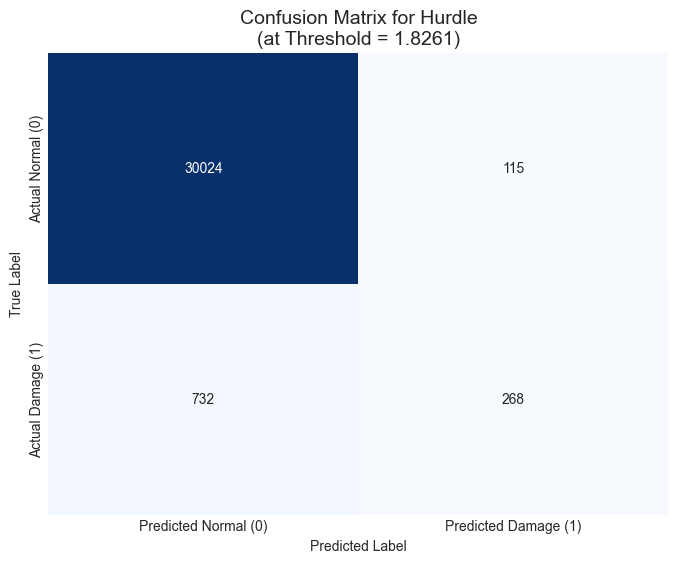


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.98      1.00      0.99     30139
   Damage (1)       0.70      0.27      0.39      1000

     accuracy                           0.97     31139
    macro avg       0.84      0.63      0.69     31139
 weighted avg       0.97      0.97      0.97     31139



--- 2. Overall Classifier Performance ---



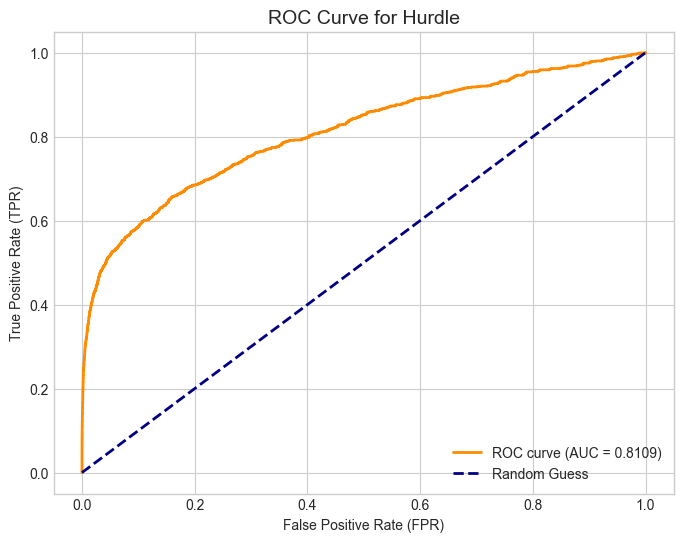

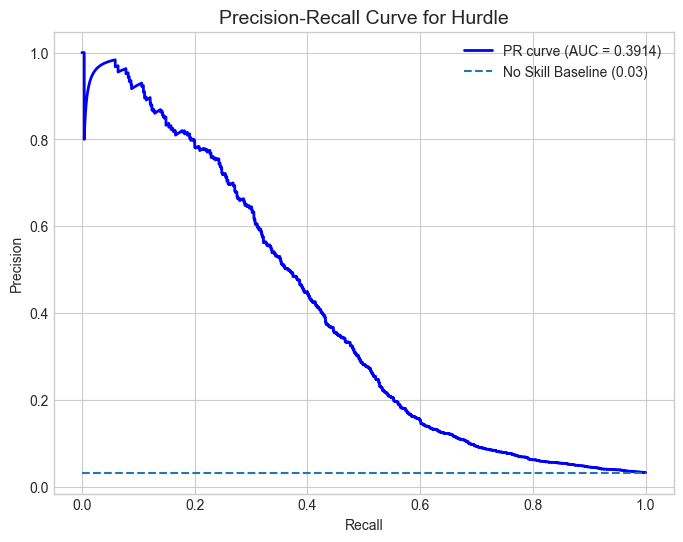

AUC-ROC Score: 0.8109
AUC-PR Score (Average Precision): 0.3914


--- 3. Damage Prediction Visualization ---



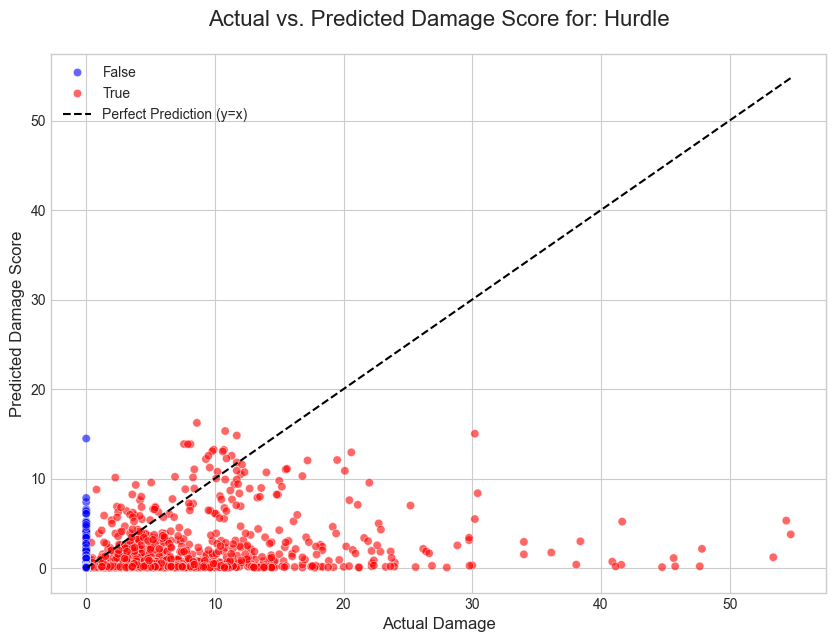

==================== END DIAGNOSTICS FOR: Hurdle ====================


==================== DIAGNOSTICS FOR: Combined ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step
Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step
Identified 2 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -7871.00
  🖯 Optimal Threshold: 1.0000
---------------


--- 1. Performance at Optimal Threshold ---



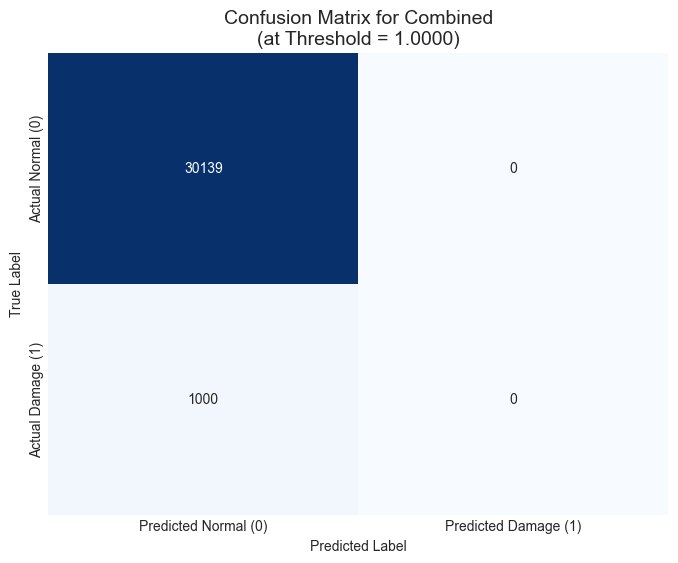


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.97      1.00      0.98     30139
   Damage (1)       0.00      0.00      0.00      1000

     accuracy                           0.97     31139
    macro avg       0.48      0.50      0.49     31139
 weighted avg       0.94      0.97      0.95     31139



--- 2. Overall Classifier Performance ---



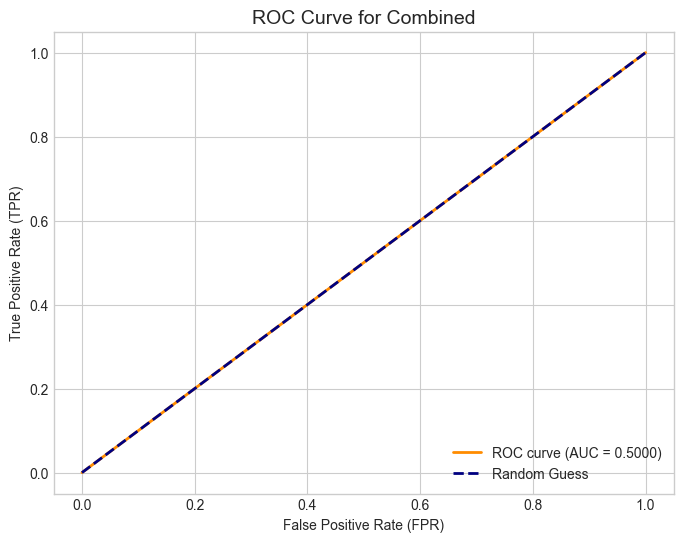

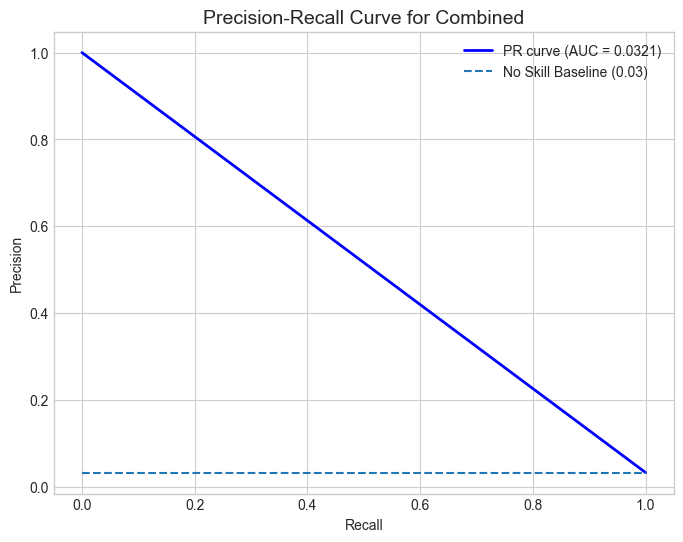

AUC-ROC Score: 0.5000
AUC-PR Score (Average Precision): 0.0321


--- 3. Damage Prediction Visualization ---



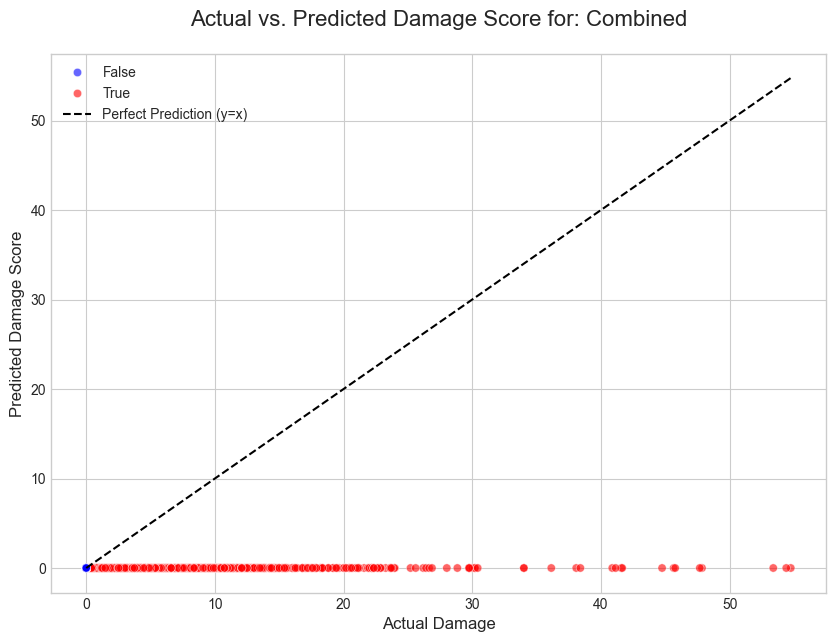

==================== END DIAGNOSTICS FOR: Combined ====================


==================== DIAGNOSTICS FOR: XGBoost ====================
Generating predictions from the model...
Identified 3 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -4958.11
  🖯 Optimal Threshold: 1.0000
---------------


--- 1. Performance at Optimal Threshold ---



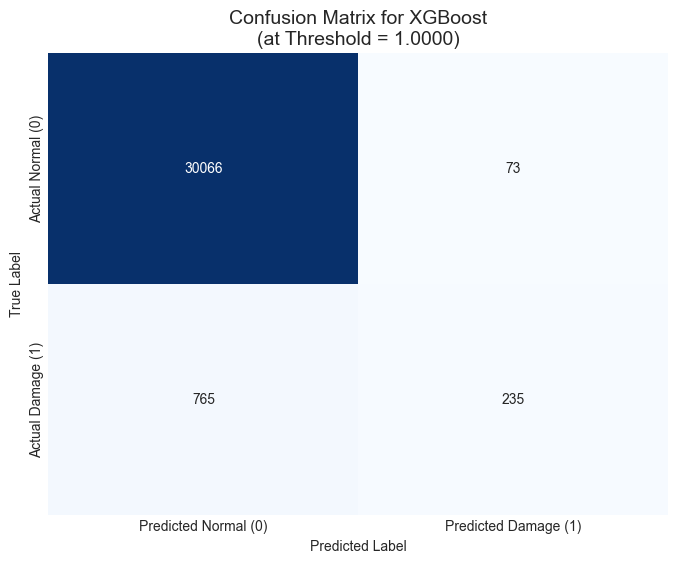


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.98      1.00      0.99     30139
   Damage (1)       0.76      0.23      0.36      1000

     accuracy                           0.97     31139
    macro avg       0.87      0.62      0.67     31139
 weighted avg       0.97      0.97      0.97     31139



--- 2. Overall Classifier Performance ---



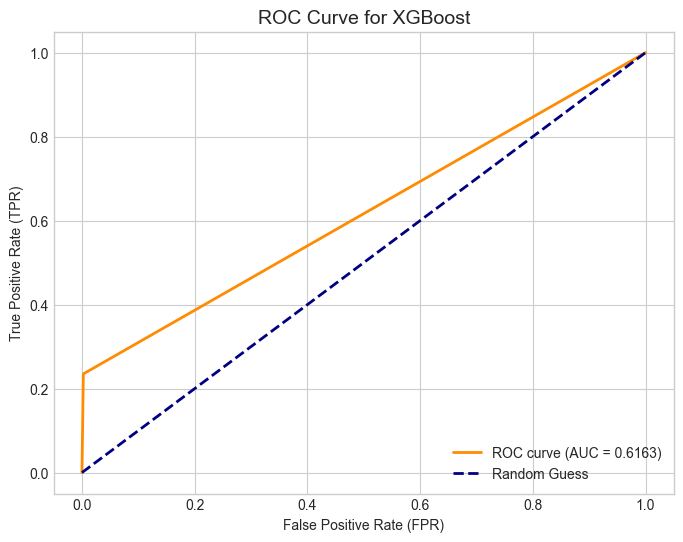

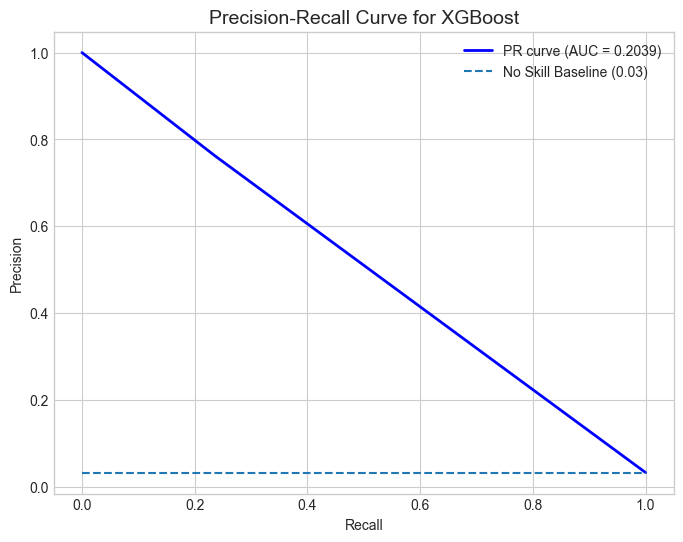

AUC-ROC Score: 0.6163
AUC-PR Score (Average Precision): 0.2039


--- 3. Damage Prediction Visualization ---



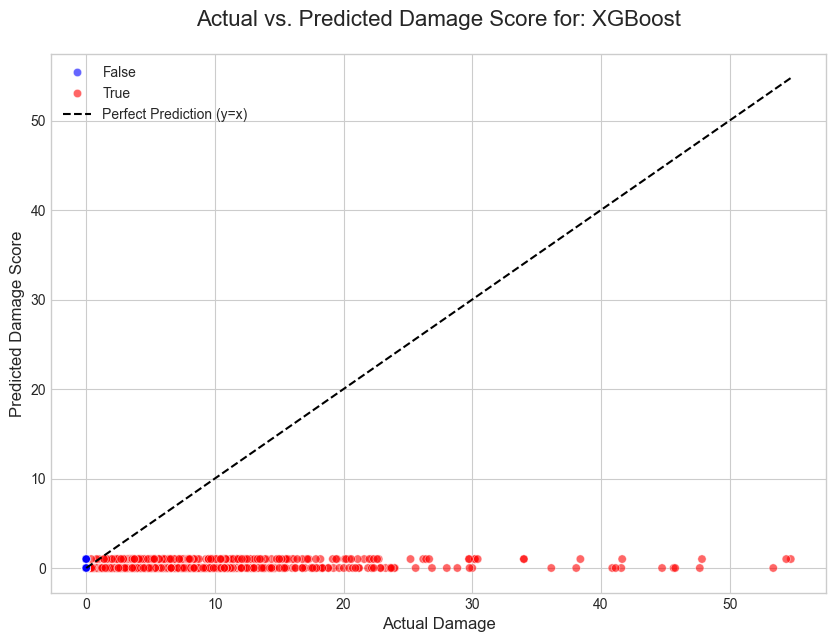

==================== END DIAGNOSTICS FOR: XGBoost ====================


==================== DIAGNOSTICS FOR: Tweedie ====================
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step
Generating predictions from the model...
974/974 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step
Identified 2 unique thresholds to test.

--- Summary ---
  🏆 Best Custom Score: -7871.00
  🖯 Optimal Threshold: 1.0000
---------------


--- 1. Performance at Optimal Threshold ---



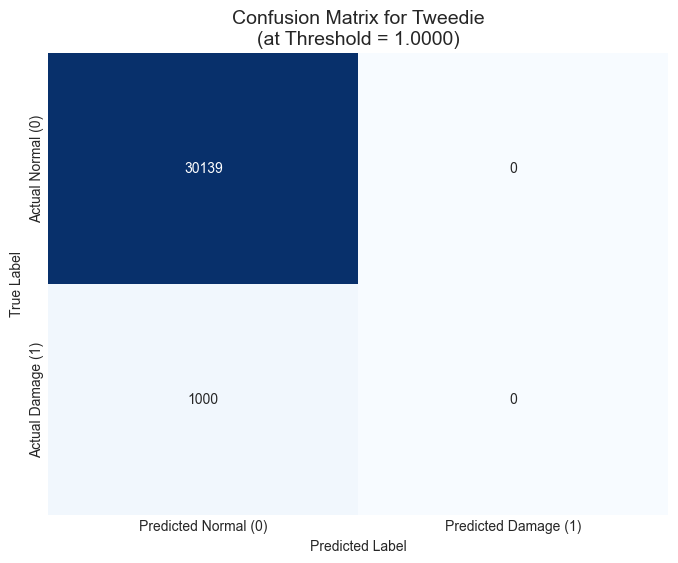


Classification Report:
               precision    recall  f1-score   support

No Damage (0)       0.97      1.00      0.98     30139
   Damage (1)       0.00      0.00      0.00      1000

     accuracy                           0.97     31139
    macro avg       0.48      0.50      0.49     31139
 weighted avg       0.94      0.97      0.95     31139



--- 2. Overall Classifier Performance ---



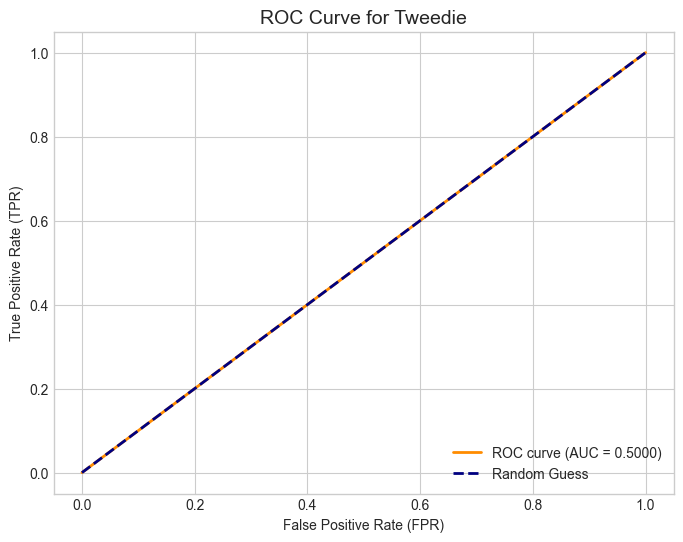

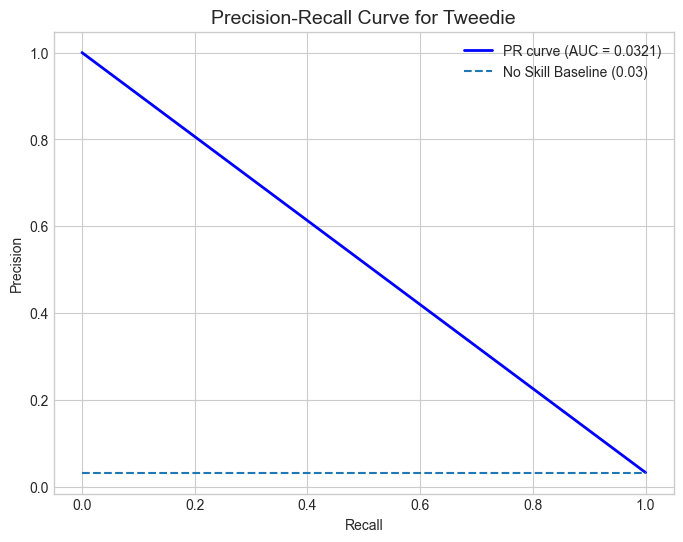

AUC-ROC Score: 0.5000
AUC-PR Score (Average Precision): 0.0321


--- 3. Damage Prediction Visualization ---



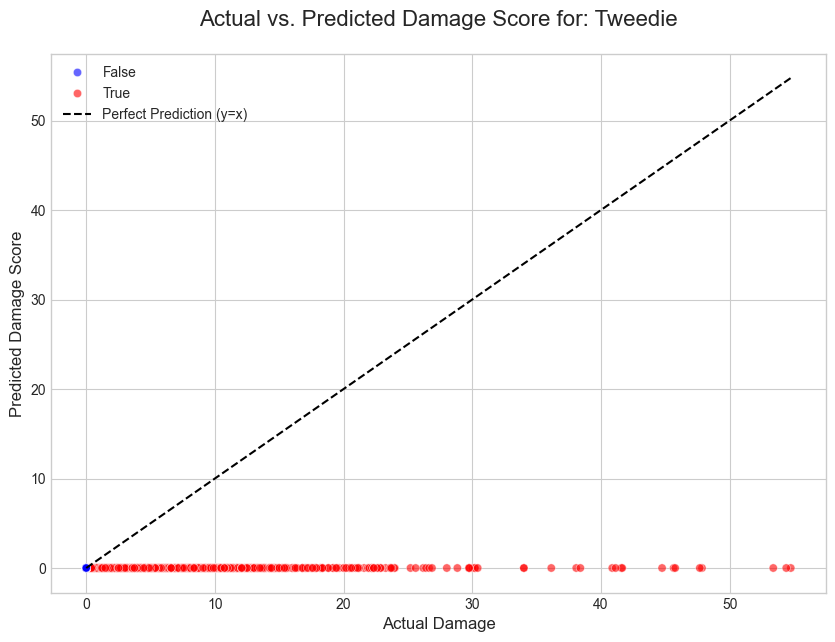

==================== END DIAGNOSTICS FOR: Tweedie ====================




In [39]:
generate_model_diagnostics(models_to_evaluate, X_test_processed, y_test, Z_damage_test)